In [1]:

# Import standard libraries
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add code directory to path
sys.path.insert(0, os.path.join(os.getcwd(), 'code'))

# Import custom modules (without 'code.' prefix)
from model import create_fdi_model, get_model_info, FDI_Dataset
from dataloader import load_all_data, print_data_statistics
from train import train_model, save_checkpoint
from evaluate import evaluate_model, save_results, print_classification_report
from utils import (
    set_seed, get_device, print_model_info, print_header, print_metrics,
    plot_confusion_matrix, plot_training_curves, plot_roc_pr_curves,
    create_experiment_dir
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All modules imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✅ All modules imported successfully!
PyTorch version: 2.2.1
CUDA available: True
CUDA device: NVIDIA A100-PCIE-40GB


In [2]:

# Common Configuration


# Configuration
SEED = 42
DEVICE_NAME = 'cuda:1'  # 'auto', 'cuda', 'cuda:0', 'cpu'
DATA_DIR = 'data/'

# Set random seed for reproducibility
set_seed(SEED)

# Get device
device = get_device(DEVICE_NAME)

print("\n" + "="*70)
print("Configuration:")
print("="*70)
print(f"Random Seed: {SEED}")
print(f"Device: {device}")
print(f"Data Directory: {DATA_DIR}")
print("="*70 + "\n")

✅ Random seed set to 42
✅ Using device: cuda:1
   GPU: NVIDIA A100-PCIE-40GB
   Memory: 42.30 GB

Configuration:
Random Seed: 42
Device: cuda:1
Data Directory: data/



In [3]:
"""
=============================================================================
PART 1: BINARY CLASSIFICATION
=============================================================================
"""

print_header("BINARY CLASSIFICATION - Data Loading", width=70)

# Binary classification configuration
binary_config = {
    'task': 'binary',
    'num_classes': 2,
    'embedding_dim': 256,
    'batch_size': 512,
    'num_epochs': 300,
    'learning_rate': 0.0005,
    'weight_decay': 1e-4,
    'patience': 50,
    'focal_gamma': 2.0,
    'focal_alpha': 0.25,
    'kg_layers': 3,
    'kg_bases': 8,
    'kg_dropout': 0.1,
    'pred_layers': 4,
    'pred_dropout': 0.2,
    'use_attention': True,
    'use_batch_norm': True,
    'num_heads': 4,
    'scheduler_factor': 0.5,
    'scheduler_patience': 5,
    'min_delta': 1e-4,
    'seed': SEED,
    'num_workers': 4
}

# Load binary data
binary_data = load_all_data(
    task='binary',
    batch_size=binary_config['batch_size'],
    num_workers=binary_config['num_workers'],
    data_dir=DATA_DIR
)

# Move graph to GPU
print(f"\n🔄 Moving graph to {device}...")
binary_data['graph'] = binary_data['graph'].to(device)
print(f"✅ Graph moved to {device}")

# Print data statistics
print_data_statistics(
    binary_data['train_loader'],
    binary_data['val_loader'],
    binary_data['test_loader'],
    task='binary'
)

print(f"\n✅ Binary data loaded successfully!")
print(f"   - Train batches: {len(binary_data['train_loader'])}")
print(f"   - Val batches: {len(binary_data['val_loader'])}")
print(f"   - Test batches: {len(binary_data['test_loader'])}")
print(f"   - Graph on device: {binary_data['graph'].device}")


                 BINARY CLASSIFICATION - Data Loading                 

🚀 Loading data for BINARY classification

✅ Graph loaded: 41,698 nodes, 2,937,632 edges
✅ Mappings loaded: 41,698 entities, 73 relations

✅ Train: 2,627 samples
✅ Val:   328 samples
✅ Test:  329 samples
✅ Class weights loaded

✅ DataLoaders created (batch_size=512)



🔄 Moving graph to cuda:1...
✅ Graph moved to cuda:1

📊 Dataset Statistics

Train: 2,627 samples
  Positive: 1,314 (50.0%)
  Negative: 1,313 (50.0%)

Val: 328 samples
  Positive: 164 (50.0%)
  Negative: 164 (50.0%)

Test: 329 samples
  Positive: 164 (49.8%)
  Negative: 165 (50.2%)



✅ Binary data loaded successfully!
   - Train batches: 6
   - Val batches: 1
   - Test batches: 1
   - Graph on device: cuda:1


In [4]:
# Binary Model Initialization


print_header("BINARY CLASSIFICATION - Model Initialization", width=70)

# Add class weights to config
if binary_data['class_weights'] is not None:
    binary_config['class_weights'] = binary_data['class_weights'].to(device)

# Create binary model
binary_model = create_fdi_model(
    binary_config,
    num_entities=binary_data['mappings']['num_nodes'],
    num_relations=binary_data['mappings']['num_relations'],
    device=device
)

# Print model information
print_model_info(binary_model)

print("✅ Binary model initialized successfully!")


             BINARY CLASSIFICATION - Model Initialization             


Model Information
Total parameters:       25,634,817
Trainable parameters:   25,634,817
Non-trainable parameters: 0
Model size (MB):        97.79

✅ Binary model initialized successfully!


In [ ]:
# Optional: skip training and load the released pretrained weights instead
# (see data/README.md for the Zenodo download link -- best_model_binary.pt)
LOAD_PRETRAINED_BINARY = False  # set True to skip training below

if LOAD_PRETRAINED_BINARY:
    from train import load_checkpoint
    binary_trained_model = load_checkpoint(
        binary_model, 'data/best_model_binary.pt', device=device
    )
    binary_history = None
    print("Loaded pretrained binary model weights; skipping training.")


In [5]:
# Binary Model Training


print_header("BINARY CLASSIFICATION - Training", width=70)

if not LOAD_PRETRAINED_BINARY:
    # Train binary model
    binary_trained_model, binary_history = train_model(
        binary_model,
        binary_data['train_loader'],
        binary_data['val_loader'],
        binary_data['graph'],
        binary_config,
        device=device
    )

    print("\n✅ Binary model training completed!")
    print(f"   Best validation F1: {max(binary_history['val_f1']):.4f}")
else:
    print("Skipping training (LOAD_PRETRAINED_BINARY=True).")


                   BINARY CLASSIFICATION - Training                   


Starting training: BINARY classification
Epochs: 300
Learning rate: 0.0005
Patience: 50


Epoch 1/300
----------------------------------------------------------------------


Train Loss: 0.1633
Val Loss:   0.0729
Val F1:     0.3483
LR:         0.000500
✅ New best F1: 0.3483

Epoch 2/300
----------------------------------------------------------------------


Train Loss: 0.0666
Val Loss:   0.0577
Val F1:     0.4909
LR:         0.000500
✅ New best F1: 0.4909

Epoch 3/300
----------------------------------------------------------------------


Train Loss: 0.0574
Val Loss:   0.0552
Val F1:     0.6912
LR:         0.000500
✅ New best F1: 0.6912

Epoch 4/300
----------------------------------------------------------------------


Train Loss: 0.0551
Val Loss:   0.0606
Val F1:     0.6934
LR:         0.000500
✅ New best F1: 0.6934

Epoch 5/300
----------------------------------------------------------------------


...

Train Loss: 0.0171
Val Loss:   0.0838
Val F1:     0.8205
LR:         0.000001

Epoch 99/300
----------------------------------------------------------------------


Train Loss: 0.0159
Val Loss:   0.0837
Val F1:     0.8205
LR:         0.000001

Epoch 100/300
----------------------------------------------------------------------


Train Loss: 0.0185
Val Loss:   0.0839
Val F1:     0.8205
LR:         0.000001

Epoch 101/300
----------------------------------------------------------------------


Train Loss: 0.0164
Val Loss:   0.0839
Val F1:     0.8205
LR:         0.000001

Epoch 102/300
----------------------------------------------------------------------


Train Loss: 0.0166
Val Loss:   0.0837
Val F1:     0.8205
LR:         0.000001

⚠️  Early stopping triggered after 102 epochs

Training completed!
Best validation F1: 0.8243


✅ Binary model training completed!
   Best validation F1: 0.8243


In [6]:
# Binary Model Evaluation


print_header("BINARY CLASSIFICATION - Evaluation", width=70)

# Evaluate on test set
binary_results = evaluate_model(
    binary_trained_model,
    binary_data['test_loader'],
    binary_data['graph'],
    device,
    task='binary',
    num_classes=2
)

# Save results
save_results(binary_results, 'results/binary', 'test_results.json')

# Print detailed metrics
print_metrics(binary_results['metrics'], task='binary')

# Print classification report
y_true_binary = np.array(binary_results['predictions']['y_true'])
y_pred_binary = np.array(binary_results['predictions']['y_pred'])
print_classification_report(
    y_true_binary, 
    y_pred_binary, 
    class_names=['Negative', 'Positive'], 
    task='binary'
)

print("✅ Binary model evaluation completed!")


                  BINARY CLASSIFICATION - Evaluation                  


Evaluating BINARY classification model



Evaluating: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]


Test Results:
Accuracy:  0.8267
Precision: 0.8591
Recall:    0.7805
F1 Score:  0.8179
AUC-ROC:   0.9050
AUC-PR:    0.8889

✅ Results saved: results/binary/test_results.json

Metrics:
Accuracy:   0.8267
Precision:  0.8591
Recall:     0.7805
F1 Score:   0.8179
AUC-ROC:    0.9050
AUC-PR:     0.8889


Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.87      0.83       165
    Positive       0.86      0.78      0.82       164

    accuracy                           0.83       329
   macro avg       0.83      0.83      0.83       329
weighted avg       0.83      0.83      0.83       329


✅ Binary model evaluation completed!



                BINARY CLASSIFICATION - Visualization                 

✅ Training curves saved: results/binary/training_curves.png


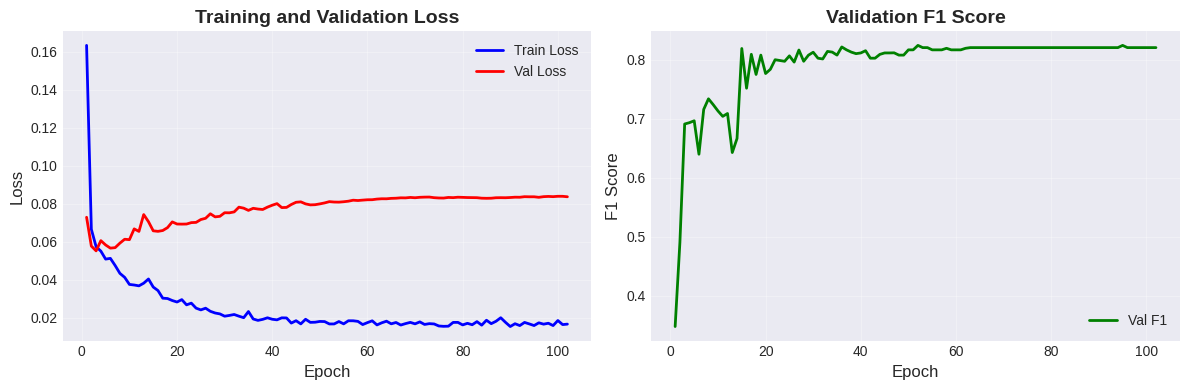

✅ Confusion matrix saved: results/binary/confusion_matrix.png


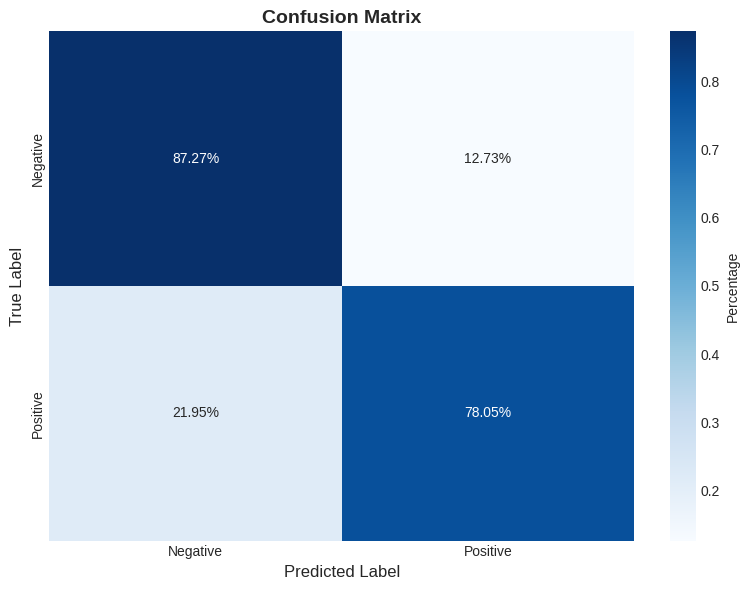

✅ ROC/PR curves saved: results/binary/roc_pr_curves.png


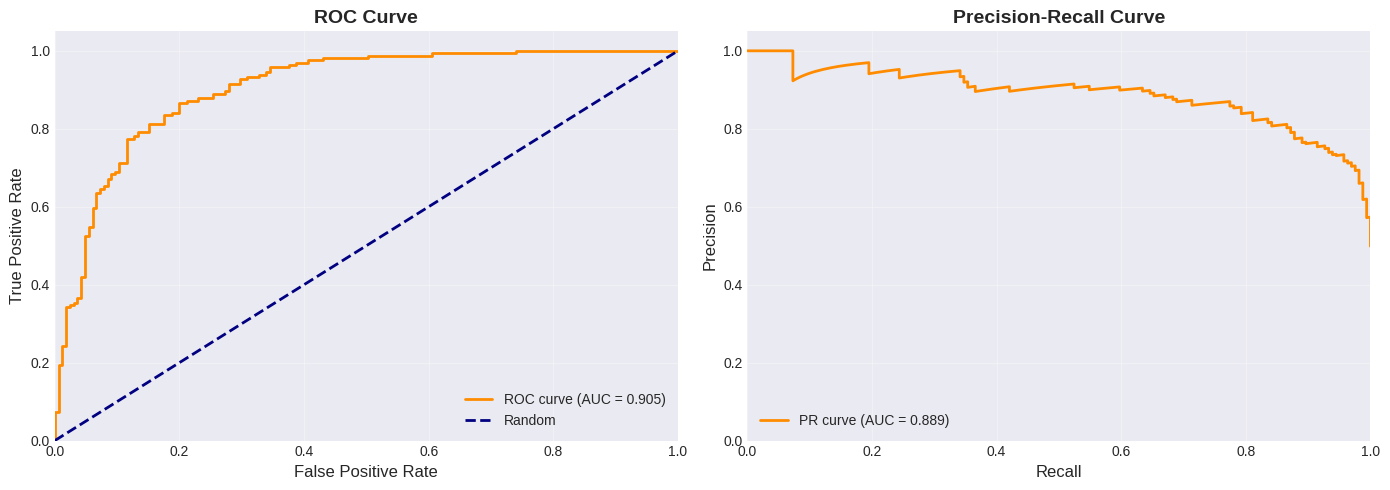


✅ Binary visualization completed!
   Figures saved to: results/binary/


In [7]:
# Binary Results Visualization


print_header("BINARY CLASSIFICATION - Visualization", width=70)

# 1. Training curves (only available if the model was trained this session)
if binary_history is not None:
    plot_training_curves(
        binary_history,
        save_path='results/binary/training_curves.png'
    )

# 2. Confusion matrix
cm_binary = np.array(binary_results['metrics']['confusion_matrix'])
plot_confusion_matrix(
    cm_binary,
    class_names=['Negative', 'Positive'],
    save_path='results/binary/confusion_matrix.png',
    figsize=(8, 6)
)

# 3. ROC and PR curves
y_proba_binary = np.array(binary_results['predictions']['y_proba'])
plot_roc_pr_curves(
    y_true_binary,
    y_proba_binary,
    save_dir='results/binary'
)

print("\n✅ Binary visualization completed!")
print(f"   Figures saved to: results/binary/")

In [8]:
"""
=============================================================================
PART 2: MULTI-CLASS CLASSIFICATION
=============================================================================
"""

print_header("MULTI-CLASS CLASSIFICATION - Data Loading", width=70)

# Multi-class configuration
# Reproduces the configuration selected via the 144-configuration grid
# search reported in Supplementary File 5 (embedding_dim=256, 3 R-GCN
# layers, gamma=1.0, 4 attention heads). kg_bases is left unset so each
# relation gets its own full weight matrix, matching the architecture
# described in the manuscript (no basis decomposition for the multi-class
# model).
multi_config = {
    'task': 'multi',
    'num_classes': 4,
    'embedding_dim': 256,
    'batch_size': 64,
    'num_epochs': 200,
    'learning_rate': 0.0005,
    'weight_decay': 1e-4,
    'patience': 30,
    'focal_gamma': 1.0,
    'focal_alpha': None,  # Will use class weights
    'kg_layers': 3,
    'kg_bases': None,
    'kg_dropout': 0.1,
    'pred_layers': 3,
    'pred_dropout': 0.2,
    'use_attention': True,
    'use_batch_norm': True,
    'num_heads': 4,
    'scheduler_factor': 0.5,
    'scheduler_patience': 5,
    'min_delta': 1e-4,
    'seed': SEED,
    'num_workers': 4
}

# Load multi-class data
multi_data = load_all_data(
    task='multi',
    batch_size=multi_config['batch_size'],
    num_workers=multi_config['num_workers'],
    data_dir=DATA_DIR
)

# Move graph to GPU
print(f"\n🔄 Moving graph to {device}...")
multi_data['graph'] = multi_data['graph'].to(device)
print(f"✅ Graph moved to {device}")

# Print data statistics
print_data_statistics(
    multi_data['train_loader'],
    multi_data['val_loader'],
    multi_data['test_loader'],
    task='multi'
)

print(f"\n✅ Multi-class data loaded successfully!")
print(f"   - Train batches: {len(multi_data['train_loader'])}")
print(f"   - Val batches: {len(multi_data['val_loader'])}")
print(f"   - Test batches: {len(multi_data['test_loader'])}")
print(f"   - Graph on device: {multi_data['graph'].device}")


              MULTI-CLASS CLASSIFICATION - Data Loading               

🚀 Loading data for MULTI classification

✅ Graph loaded: 41,698 nodes, 2,937,632 edges
✅ Mappings loaded: 41,698 entities, 73 relations

✅ Train: 1,149 samples
✅ Val:   246 samples
✅ Test:  247 samples
✅ Class weights loaded

✅ DataLoaders created (batch_size=64)



🔄 Moving graph to cuda:1...
✅ Graph moved to cuda:1

📊 Dataset Statistics

Train: 1,149 samples
  Class distribution:
    Class 0: 846
    Class 1: 216
    Class 2: 59
    Class 3: 28

Val: 246 samples
  Class distribution:
    Class 0: 181
    Class 1: 46
    Class 2: 13
    Class 3: 6

Test: 247 samples
  Class distribution:
    Class 0: 182
    Class 1: 47
    Class 2: 12
    Class 3: 6



✅ Multi-class data loaded successfully!
   - Train batches: 18
   - Val batches: 4
   - Test batches: 4
   - Graph on device: cuda:1


In [9]:
# Multi-class Model Initialization


print_header("MULTI-CLASS CLASSIFICATION - Model Initialization", width=70)

# Add class weights to config
if multi_data['class_weights'] is not None:
    multi_config['class_weights'] = multi_data['class_weights'].to(device)

# Create multi-class model
multi_model = create_fdi_model(
    multi_config,
    num_entities=multi_data['mappings']['num_nodes'],
    num_relations=multi_data['mappings']['num_relations'],
    device=device
)

# Print model information
print_model_info(multi_model)

print("✅ Multi-class model initialized successfully!")


          MULTI-CLASS CLASSIFICATION - Model Initialization           


Model Information
Total parameters:       10,368,132
Trainable parameters:   10,368,132
Non-trainable parameters: 0
Model size (MB):        39.55

✅ Multi-class model initialized successfully!


In [ ]:
# Optional: skip training and load the released pretrained weights instead
# (see data/README.md for the Zenodo download link -- best_model.pt,
# the checkpoint that produced the Table 3 results)
LOAD_PRETRAINED_MULTI = False  # set True to skip training below

if LOAD_PRETRAINED_MULTI:
    from train import load_checkpoint
    multi_trained_model = load_checkpoint(
        multi_model, 'data/best_model.pt', device=device
    )
    multi_history = None
    print("Loaded pretrained multi-class model weights; skipping training.")


In [10]:
# Multi-class Model Training


print_header("MULTI-CLASS CLASSIFICATION - Training", width=70)

if not LOAD_PRETRAINED_MULTI:
    # Train multi-class model
    multi_trained_model, multi_history = train_model(
        multi_model,
        multi_data['train_loader'],
        multi_data['val_loader'],
        multi_data['graph'],
        multi_config,
        device=device
    )

    print("\n✅ Multi-class model training completed!")
    print(f"   Best validation F1: {max(multi_history['val_f1']):.4f}")
else:
    print("Skipping training (LOAD_PRETRAINED_MULTI=True).")


                MULTI-CLASS CLASSIFICATION - Training                 


Starting training: MULTI classification
Epochs: 200
Learning rate: 0.0005
Patience: 30


Epoch 1/200
----------------------------------------------------------------------


Train Loss: 1.1388
Val Loss:   0.9347
Val F1:     0.1519
LR:         0.000500
✅ New best F1: 0.1519

Epoch 2/200
----------------------------------------------------------------------


Train Loss: 0.6883
Val Loss:   0.8085
Val F1:     0.6678
LR:         0.000500
✅ New best F1: 0.6678

Epoch 3/200
----------------------------------------------------------------------


Train Loss: 0.5495
Val Loss:   0.6294
Val F1:     0.4758
LR:         0.000500

Epoch 4/200
----------------------------------------------------------------------


Train Loss: 0.3978
Val Loss:   0.7234
Val F1:     0.5709
LR:         0.000500

Epoch 5/200
----------------------------------------------------------------------


...

Train Loss: 0.0019
Val Loss:   1.6492
Val F1:     0.8529
LR:         0.000008

Epoch 85/200
----------------------------------------------------------------------


Train Loss: 0.0015
Val Loss:   1.6496
Val F1:     0.8568
LR:         0.000008

Epoch 86/200
----------------------------------------------------------------------


Train Loss: 0.0015
Val Loss:   1.6519
Val F1:     0.8568
LR:         0.000008

Epoch 87/200
----------------------------------------------------------------------


Train Loss: 0.0011
Val Loss:   1.6526
Val F1:     0.8529
LR:         0.000008

Epoch 88/200
----------------------------------------------------------------------


Train Loss: 0.0013
Val Loss:   1.6604
Val F1:     0.8529
LR:         0.000004

⚠️  Early stopping triggered after 88 epochs

Training completed!
Best validation F1: 0.8663


✅ Multi-class model training completed!
   Best validation F1: 0.8663


In [11]:
# Multi-class Model Evaluation


print_header("MULTI-CLASS CLASSIFICATION - Evaluation", width=70)

# Evaluate on test set
multi_results = evaluate_model(
    multi_trained_model,
    multi_data['test_loader'],
    multi_data['graph'],
    device,
    task='multi',
    num_classes=4
)

# Save results
save_results(multi_results, 'results/multi', 'test_results.json')

# Print detailed metrics
print_metrics(multi_results['metrics'], task='multi')

# Print classification report
y_true_multi = np.array(multi_results['predictions']['y_true'])
y_pred_multi = np.array(multi_results['predictions']['y_pred'])
print_classification_report(
    y_true_multi,
    y_pred_multi,
    class_names=['Possible', 'Positive', 'Negative', 'Harmful'],
    task='multi'
)

print("✅ Multi-class model evaluation completed!")


               MULTI-CLASS CLASSIFICATION - Evaluation                


Evaluating MULTI classification model



Evaluating: 100%|██████████| 4/4 [00:00<00:00,  4.38it/s]


Test Results:
Accuracy:      0.8502
Kappa:         0.6495
F1 (Weighted): 0.8566
F1 (Macro):    0.6403
AUC-ROC (W):   0.8971
AUC-PR (W):    0.8952

✅ Results saved: results/multi/test_results.json

Metrics:
Accuracy:       0.8502
Kappa:          0.6495
F1 (Weighted):  0.8566
F1 (Macro):     0.6403
AUC-ROC (W):    0.8971
AUC-PR (W):     0.8952


Classification Report:
              precision    recall  f1-score   support

    Possible       0.92      0.91      0.92       182
    Positive       0.83      0.72      0.77        47
    Negative       0.47      0.58      0.52        12
     Harmful       0.27      0.50      0.35         6

    accuracy                           0.85       247
   macro avg       0.62      0.68      0.64       247
weighted avg       0.87      0.85      0.86       247


✅ Multi-class model evaluation completed!



              MULTI-CLASS CLASSIFICATION - Visualization              

✅ Training curves saved: results/multi/training_curves.png


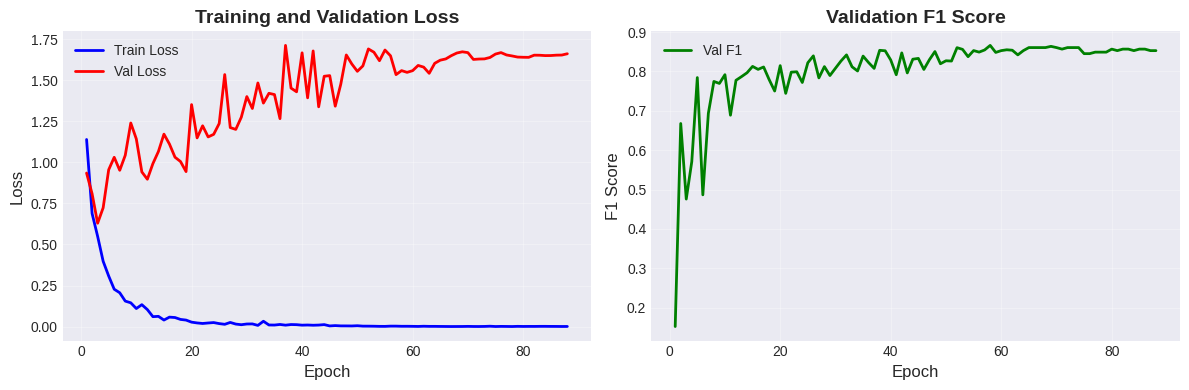

✅ Confusion matrix saved: results/multi/confusion_matrix.png


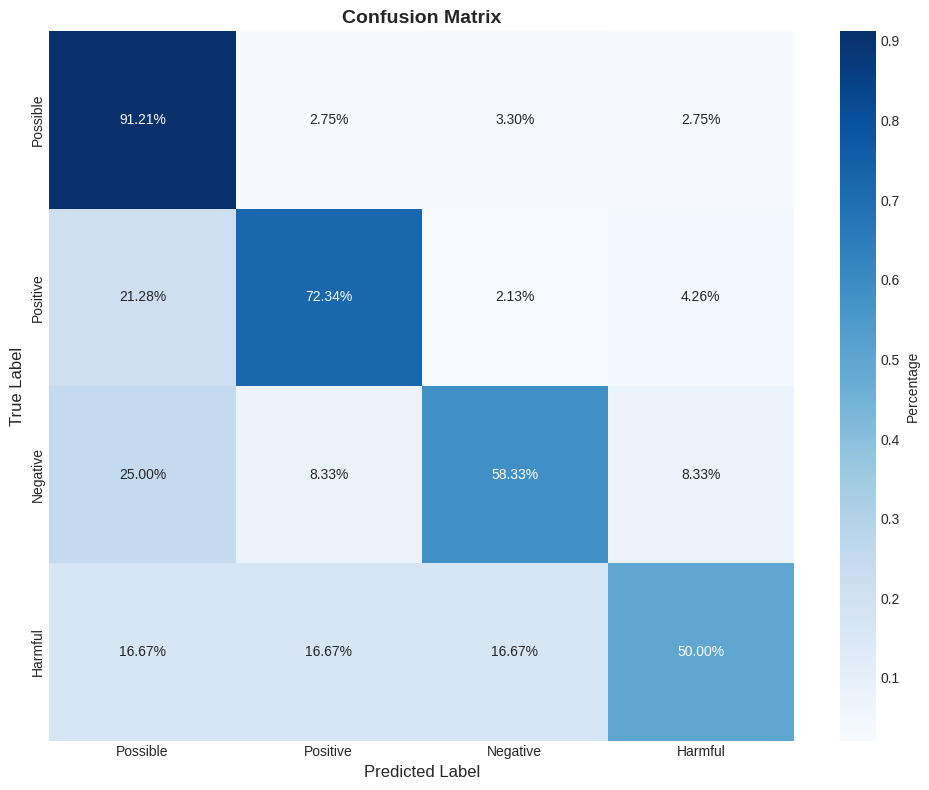


✅ Multi-class visualization completed!
   Figures saved to: results/multi/


In [12]:
# Multi-class Results Visualization


print_header("MULTI-CLASS CLASSIFICATION - Visualization", width=70)

# 1. Training curves (only available if the model was trained this session)
if multi_history is not None:
    plot_training_curves(
        multi_history,
        save_path='results/multi/training_curves.png'
    )

# 2. Confusion matrix
cm_multi = np.array(multi_results['metrics']['confusion_matrix'])
plot_confusion_matrix(
    cm_multi,
    class_names=['Possible', 'Positive', 'Negative', 'Harmful'],
    save_path='results/multi/confusion_matrix.png',
    figsize=(10, 8)
)

print("\n✅ Multi-class visualization completed!")
print(f"   Figures saved to: results/multi/")